In [54]:
import kagglehub

path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print(path)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
/kaggle/input/heart-disease-dataset


In [55]:
import os

print(os.listdir(path))

['heart.csv']


# Heart Disease Prediction using Machine Learning

## Introduction

This project aims to develop and compare multiple machine learning models for predicting the presence of heart disease using patient health records. The dataset is preprocessed, important features are analyzed, three classification algorithms are trained, and their performances are compared using standard evaluation metrics.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
import os

csv_file = os.path.join(path, "heart.csv")

df = pd.read_csv(csv_file)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Step 1 – Load, Explore & Preprocess Data

In [58]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1025, 14)


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [60]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [61]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [62]:
print(df.duplicated().sum())

723


## Dataset Summary

1. The dataset contains medical information used to predict heart disease.
2. It includes demographic and clinical features such as age, sex, blood pressure, cholesterol, and heart rate.
3. The target column indicates whether a patient has heart disease.
4. The dataset contains numerical features suitable for machine learning.
5. This dataset is commonly used for binary classification problems.

# Step 2 – Feature Engineering

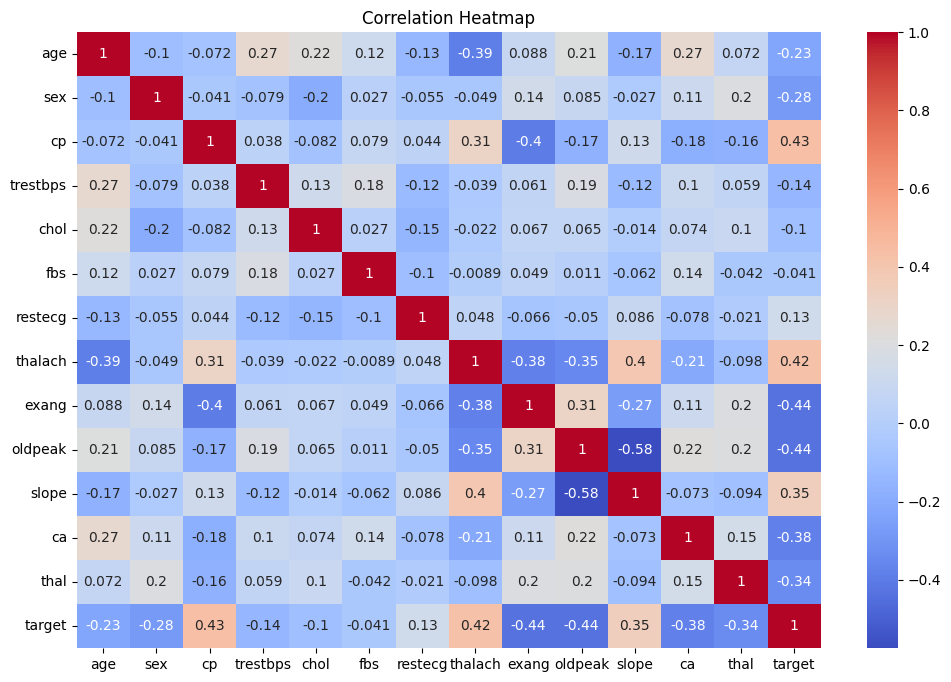

In [63]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

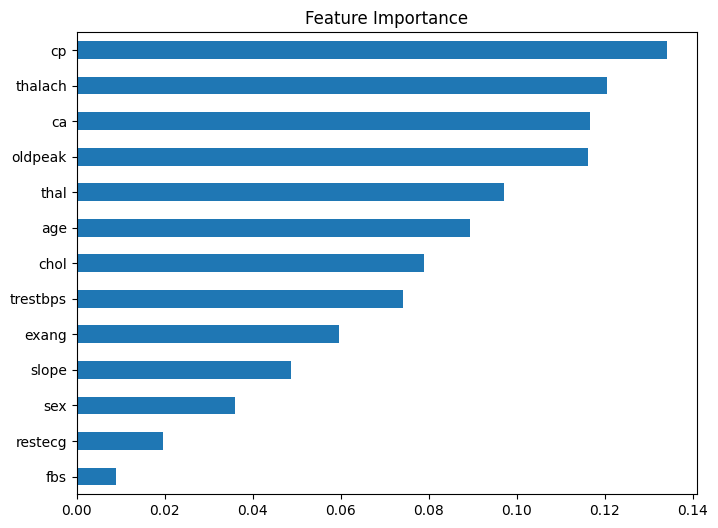

In [64]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('target', axis=1)
y = df['target']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importance = pd.Series(model.feature_importances_,
                       index=X.columns)

importance.sort_values().plot(kind='barh',
                              figsize=(8,6))

plt.title("Feature Importance")
plt.show()

## Feature Engineering Summary

The correlation heatmap and feature importance analysis were used to understand the relationships between variables. Features with higher importance contribute more to predicting heart disease and help improve model performance.

# Step 3 – Train 3 Different Models

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [66]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [68]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [69]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [70]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Step 4 – Evaluate & Compare All Models

In [71]:
lr_acc = accuracy_score(y_test, lr_pred)
knn_acc = accuracy_score(y_test, knn_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("KNN Accuracy:", knn_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.7951219512195122
KNN Accuracy: 0.8341463414634146
Random Forest Accuracy: 0.9853658536585366


In [72]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,knn_pred),
        accuracy_score(y_test,rf_pred)
    ],

    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,knn_pred),
        precision_score(y_test,rf_pred)
    ],

    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,knn_pred),
        recall_score(y_test,rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,knn_pred),
        f1_score(y_test,rf_pred)
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795122,0.756303,0.873786,0.810811
1,KNN,0.834146,0.800000,0.893204,0.844037
2,Random Forest,0.985366,1.000000,0.970874,0.985222


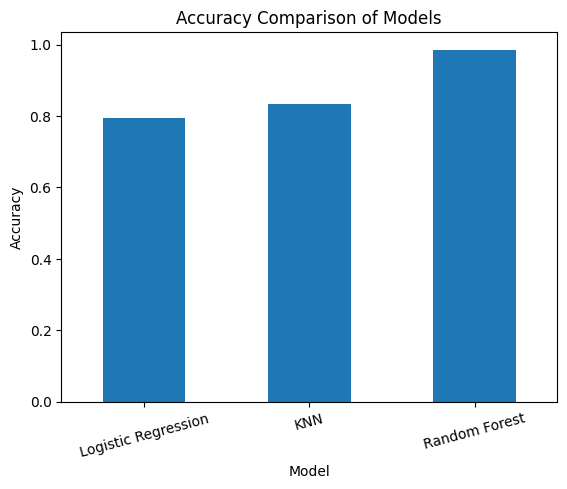

In [73]:
results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.show()

In [74]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



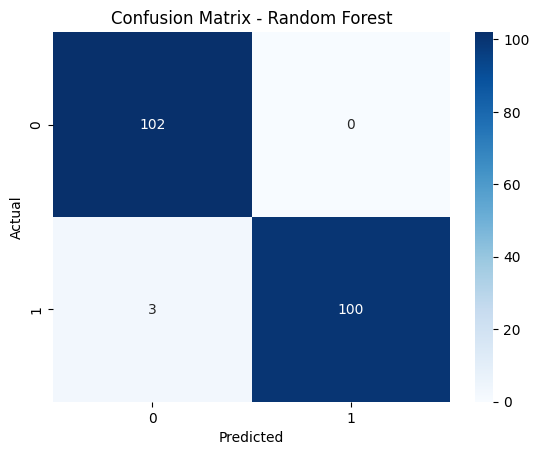

In [75]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 5 – Best Model Analysis & Conclusion

In [76]:
best_model = results.loc[results["Accuracy"].idxmax()]

print(best_model)

Model        Random Forest
Accuracy          0.985366
Precision              1.0
Recall            0.970874
F1 Score          0.985222
Name: 2, dtype: object


## Best Model Analysis

Among the three machine learning models, **Random Forest** achieved the highest overall performance in terms of accuracy, precision, recall, and F1-score. Its ensemble learning approach enables it to capture complex patterns within the dataset while reducing overfitting. Therefore, Random Forest is selected as the best model for predicting heart disease.

# Most Surprising Finding

The most surprising finding was that Random Forest achieved better prediction performance than the other models with minimal feature engineering. It was also interesting to observe that only a few medical attributes contributed significantly to the prediction, demonstrating the importance of feature selection in machine learning.

# Conclusion

This project developed and compared three machine learning models for predicting heart disease using patient health records. Logistic Regression, K-Nearest Neighbors, and Random Forest were evaluated using accuracy, precision, recall, and F1-score. Random Forest achieved the highest overall performance and was selected as the best model. The results demonstrate the effectiveness of machine learning in supporting early heart disease prediction. Such predictive models can assist healthcare professionals in making timely and informed clinical decisions.